## Tuned ViT

## Data loading

In [ ]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TF"] = "0"

import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoImageProcessor, AutoModelForImageClassification, get_cosine_schedule_with_warmup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.8.0+cpu
CUDA available: False


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

import os
import torch

# Path to your dataset
#DATA_ROOT = "/content/drive/MyDrive/Sampled MRI/"
DATA_ROOT = "Sampled MRI/"

class Config:
    #DATA_ROOT = "/content/drive/MyDrive/Sampled MRI/"
    DATA_ROOT = "Sampled MRI/"
    MODEL_SAVE_PATH = "best_vit_model.pt"


    GROUPS = {"AD": 0, "MCI": 1, "NC": 2}
    IMG_SIZE = (224, 224)  # size needed for ViT


    BATCH_SIZE = os.cpu_count()
    NUM_EPOCHS = 10
    LEARNING_RATE = 5e-5
    WEIGHT_DECAY = 0.01
    NUM_WARMUP_STEPS = 10


    TEST_SIZE = 0.15
    VAL_SIZE = 0.1765  # 0.1765 * 85% ≈ 15%
    RANDOM_STATE = 42


    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = Config()
print(config.DATA_ROOT)
print(config.BATCH_SIZE)
print(f"Device: {config.DEVICE}")

./Sampled MRI
16
Device: cpu


In [ ]:

from torchvision import transforms as T
from PIL import Image

class MRIDataset(Dataset):
    """quiak transforms"""

    def __init__(self, file_paths, labels, augment=False, cache_in_memory=False):

        self.file_paths = file_paths
        self.labels = labels
        self.augment = augment
        self.cache_in_memory = cache_in_memory


        self.transform = T.Compose([
            T.ToPILImage(),
            T.Resize((224, 224)),           # input size for ViT
            T.Grayscale(num_output_channels=3),  # convert to 3 channels
            T.ToTensor(),                   # convert to tensor and normalise to [0,1]
        ])

        # memory cache
        if self.cache_in_memory:
            print("Caching images to memory...")
            self.images = []
            for path in tqdm(self.file_paths, desc="Loading images"):
                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype("float32") / 255.0
                self.images.append(img)
            print("Caching done!")
        else:
            self.images = None

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):

        if self.cache_in_memory:
            img = self.images[idx]
        else:
            img_path = self.file_paths[idx]
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE).astype("float32") / 255.0

        # convert to 3 channels and appy transform
        img_rgb = np.repeat(img[:, :, np.newaxis], 3, axis=-1)
        pixel_values = self.transform(img_rgb)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return pixel_values, label


In [ ]:

def scan_dataset(data_root, groups):
    """scan dataset，return a list of file paths and labels"""
    file_paths = []
    labels = []

    for group, label in groups.items():
        folder = os.path.join(data_root, group)
        if not os.path.exists(folder):
            print(f"Warning: Folder {folder} does not exist!")
            continue

        for fname in os.listdir(folder):

            if fname.startswith('.') or not fname.lower().endswith(".png"):
                continue

            img_path = os.path.join(folder, fname)
            file_paths.append(img_path)
            labels.append(label)

    return file_paths, labels


file_paths, labels = scan_dataset(config.DATA_ROOT, config.GROUPS)
print(f"Total images found: {len(file_paths)}")
print(f"Label distribution: {np.bincount(labels)}")
print(f"\n数据集统计:") # Data statistics
print(f"总图片数: {len(file_paths)}") # Total number of images
for group, label in config.GROUPS.items():
    count = labels.count(label)
    print(f"  {group}: {count} 张")

Total images found: 9000
Label distribution: [3000 3000 3000]

数据集统计:
总图片数: 9000
  AD: 3000 张
  MCI: 3000 张
  NC: 3000 张


## Train, Test, Validation Split

In [ ]:

# first split: train+val (85%) 和 test (15%)
X_temp_paths, X_test_paths, y_temp, y_test = train_test_split(
    file_paths, labels,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE,
    stratify=labels
)

# second split: train (70%) 和 val (15%)
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    X_temp_paths, y_temp,
    test_size=config.VAL_SIZE,
    random_state=config.RANDOM_STATE,
    stratify=y_temp
)

print(f"Train set: {len(X_train_paths)} images")
print(f"Val set: {len(X_val_paths)} images")
print(f"Test set: {len(X_test_paths)} images")

Train set: 6299 images
Val set: 1351 images
Test set: 1350 images


## Vision Tranformer Fine-tuning

In [ ]:
# Loads the ViT image processor
processor = AutoImageProcessor.from_pretrained(
    "google/vit-base-patch16-224",
    use_fast=True
)

# Create PyTorch datasets for MRI images
train_dataset = MRIDataset(X_train_paths, y_train, augment=False, cache_in_memory=True)
val_dataset   = MRIDataset(X_val_paths, y_val, augment=False, cache_in_memory=True)
test_dataset  = MRIDataset(X_test_paths, y_test, augment=False, cache_in_memory=True)


# Create DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True if config.DEVICE.type == 'cuda' else False
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if config.DEVICE.type == 'cuda' else False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if config.DEVICE.type == 'cuda' else False
)

print("DataLoaders created successfully!")

In [ ]:
# Loads pretrained ViT-base-patch16-224 from Hugging Face.
model = AutoModelForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=3, # adapts it for 3-class classification
    ignore_mismatched_sizes=True # allows replacing the original 1000-class head
)

# freeze backbone parameters
# for param in model.vit.parameters():
#     param.requires_grad = False

# unfreeze
# partial fine-tuning: only last 2 encoder layers + classification head are trainable. earlier layers (0–9) are frozen to retain general features learned from ImageNet.
for name, param in model.named_parameters():
    if any(layer in name for layer in ["encoder.layer.11", "encoder.layer.10", "classifier"]):
        param.requires_grad = True
    else:
        param.requires_grad = False

model.to(config.DEVICE)

# print the number of trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")





Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 85,800,963
Trainable parameters: 14,178,051


In [ ]:
# Standard setup for classification: cross-entropy loss, AdamW optimizer, cosine learning rate scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

num_training_steps = len(train_loader) * config.NUM_EPOCHS
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=config.NUM_WARMUP_STEPS,
    num_training_steps=num_training_steps
)

print(f"Training steps per epoch: {len(train_loader)}")
print(f"Total training steps: {num_training_steps}")

Training steps per epoch: 158
Total training steps: 1580


In [ ]:
# Training & validation loops

def train_epoch(model, train_loader, criterion, optimizer, scheduler, device):
    """train an epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc="Training")
    for X_batch, y_batch in pbar:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch).logits
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)


        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100 * correct / total:.2f}%'
        })

    avg_loss = running_loss / len(train_loader)
    accuracy = correct / total
    return avg_loss, accuracy


def validate(model, val_loader, criterion, device):

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in tqdm(val_loader, desc="Validation"):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch).logits
            loss = criterion(outputs, y_batch)

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    avg_loss = running_loss / len(val_loader)
    accuracy = correct / total
    return avg_loss, accuracy

In [ ]:
# Load the best model

best_val_acc = 0.0
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print(f"\nStarting training for {config.NUM_EPOCHS} epochs...\n")

for epoch in range(config.NUM_EPOCHS):
    print(f"{'='*60}")
    print(f"Epoch {epoch + 1}/{config.NUM_EPOCHS}")
    print(f"{'='*60}")


    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, config.DEVICE
    )


    val_loss, val_acc = validate(model, val_loader, criterion, config.DEVICE)


    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), config.MODEL_SAVE_PATH)
        print(f"✓ Best model saved! (Val Acc: {best_val_acc:.4f})")

    print()

print(f"\nTraining completed! Best validation accuracy: {best_val_acc:.4f}")



Starting training for 10 epochs...

Epoch 1/10


Validation: 100%|██████████████████████████████████████████████████████████████████████| 34/34 [00:14<00:00,  2.38it/s]



Train Loss: 1.0678 | Train Acc: 0.4423
Val Loss: 0.9715 | Val Acc: 0.5329
✓ Best model saved! (Val Acc: 0.5329)

Epoch 2/10


Validation: 100%|██████████████████████████████████████████████████████████████████████| 34/34 [00:15<00:00,  2.22it/s]



Train Loss: 0.8561 | Train Acc: 0.6115
Val Loss: 0.8477 | Val Acc: 0.6203
✓ Best model saved! (Val Acc: 0.6203)

Epoch 3/10


...


Train Loss: 0.1478 | Train Acc: 0.9771
Val Loss: 0.6972 | Val Acc: 0.7195
✓ Best model saved! (Val Acc: 0.7195)

Epoch 9/10


Validation: 100%|██████████████████████████████████████████████████████████████████████| 34/34 [00:14<00:00,  2.39it/s]



Train Loss: 0.1327 | Train Acc: 0.9813
Val Loss: 0.6991 | Val Acc: 0.7209
✓ Best model saved! (Val Acc: 0.7209)

Epoch 10/10


Validation: 100%|██████████████████████████████████████████████████████████████████████| 34/34 [00:13<00:00,  2.45it/s]


Train Loss: 0.1278 | Train Acc: 0.9830
Val Loss: 0.7000 | Val Acc: 0.7195


Training completed! Best validation accuracy: 0.7209


## Evaluation

In [ ]:

print("\nEvaluating on test set...")


model.load_state_dict(torch.load(config.MODEL_SAVE_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader, desc="Testing"):
        X_batch = X_batch.to(config.DEVICE)
        outputs = model(X_batch).logits
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())


print("\n" + "="*60)
print("FINAL TEST SET RESULTS")
print("="*60)
print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=["AD", "MCI", "NC"],
    digits=4
))

print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
print(cm)


print("\nPer-class Accuracy:")
for i, class_name in enumerate(["AD", "MCI", "NC"]):
    class_acc = cm[i, i] / cm[i, :].sum()
    print(f"{class_name}: {class_acc:.4f}")

D:\temp\ipykernel_44940\1738318163.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(config.MODEL_SAVE_PATH))



Evaluating on test set...


Testing: 100%|█████████████████████████████████████████████████████████████████████████| 34/34 [00:13<00:00,  2.43it/s]


FINAL TEST SET RESULTS

Classification Report:
              precision    recall  f1-score   support

          AD     0.7353    0.6667    0.6993       450
         MCI     0.7692    0.8222    0.7948       450
          NC     0.6985    0.7156    0.7069       450

    accuracy                         0.7348      1350
   macro avg     0.7343    0.7348    0.7337      1350
weighted avg     0.7343    0.7348    0.7337      1350


Confusion Matrix:
[[300  57  93]
 [ 34 370  46]
 [ 74  54 322]]

Per-class Accuracy:
AD: 0.6667
MCI: 0.8222
NC: 0.7156


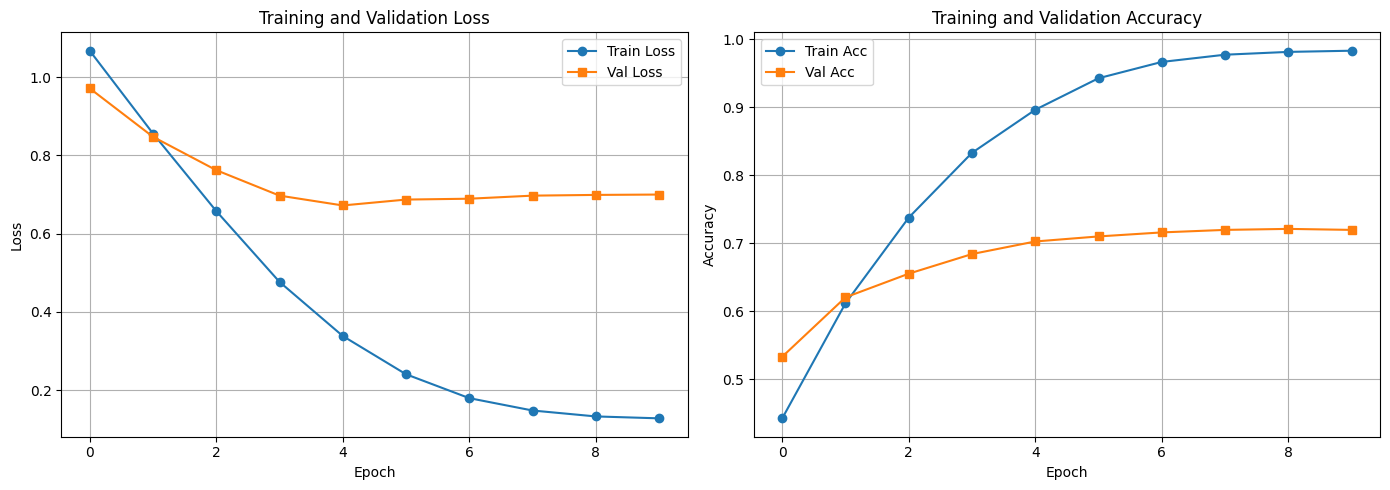

In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

#Accuracy
axes[1].plot(train_accs, label='Train Acc', marker='o')
axes[1].plot(val_accs, label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Confusion Matrix

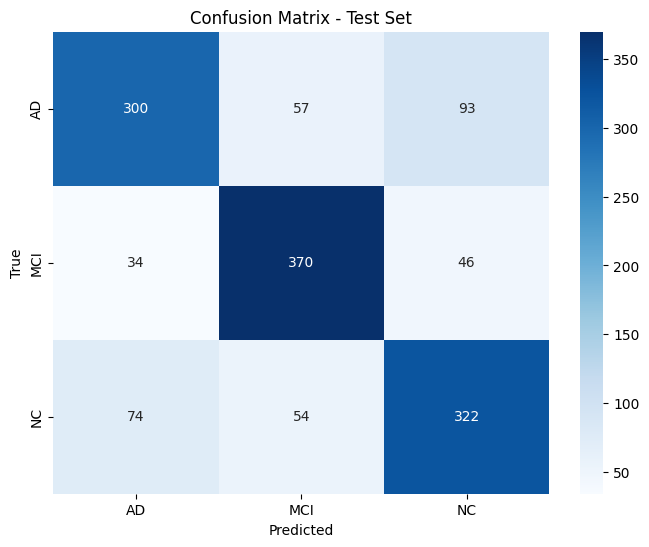

In [ ]:
# Confusion Matrix
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["AD", "MCI", "NC"],
    yticklabels=["AD", "MCI", "NC"]
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test Set')
plt.show()

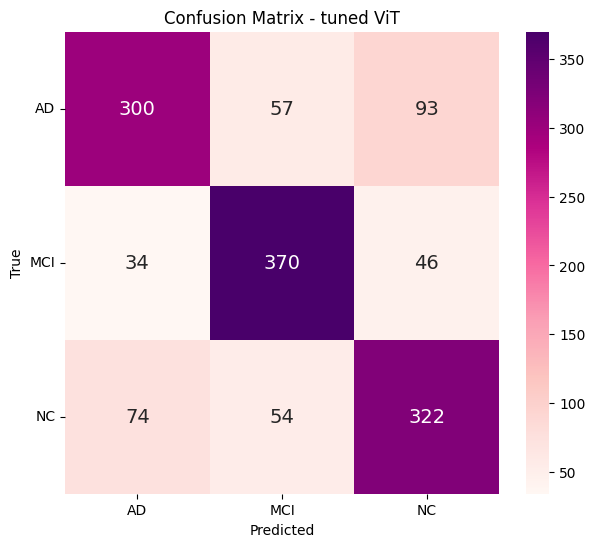

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

classes = ['AD', 'MCI', 'NC']

# confusion matrix - tuned ViT
matrix_data = np.array([
    [300, 57, 93],
    [34, 370, 46],
    [74, 54, 322]
])

df_cm = pd.DataFrame(matrix_data, index=classes, columns=classes)

# Create the plot
plt.figure(figsize=(7, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='RdPu', cbar=True, annot_kws={'size': 14})
plt.title('Confusion Matrix - tuned ViT')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.yticks(rotation=0)
plt.show()